# Preliminary Euclid VIS image simulation + FPFS detection/measurement

This example simulates a **Euclid VIS** coadd-like image with `xlens` and then
runs the `xlens` shape-measurement processor (`AnacalTask`) on it to obtain
detections and FPFS shape measurements.

Euclid-specific settings (all measured from the Euclid Q1 MER mosaics and stored
in `xlens.simulator.defaults`):

| quantity | value | source |
|---|---|---|
| pixel scale | **0.1 arcsec/pix** | MER mosaic WCS |
| VIS PSF FWHM | **0.203"** | `CATALOG-PSF` FWHM column |
| VIS noise variance (@ZP=30) | **0.135** | FLAG-masked, 3σ-clipped sky |
| mag zero point (sim) | **30.0** | common ZP (see `defaults.py`) |
| galaxy catalog | **Flagship 2** (`flagship_cosmos.fits`) | the Euclid mock |

**Preliminary / caveats**
- The PSF is a **Moffat** matched to the measured FWHM (not a true Airy) — fine
  for a first pass; swap in an Airy / real stamp later.
- This is a **noiseless** run (`draw_image_noise=False`): no noise is added to
  the pixels, but the processor still uses the measured variance (0.135) from
  the variance plane for its SNR threshold and FPFS weighting. That gives clean,
  deep detection with no false positives — good for a first look. When you do
  add noise, the real MER noise is strongly *correlated* (resampling), so a
  white-noise realisation would under-represent the noise power on object scales.
- Detection hyperparameters need tuning for Euclid (see the sweep below); the
  key one is `sigma_arcsec`.

In [1]:
import os
# Flagship catalog lives under CATSIM_DIR; set it before importing xlens so the
# task config defaults pick it up (or set config.catsim_dir explicitly below).
CATSIM = os.environ.get("CATSIM_DIR", "/home/xiangchong/.local/code/image/catsim")
os.environ.setdefault("CATSIM_DIR", CATSIM)

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

from lsst.skymap.discreteSkyMap import DiscreteSkyMap, DiscreteSkyMapConfig

from xlens.simulator.catalog import CatalogShearTask, CatalogShearTaskConfig
from xlens.simulator.sim import MultibandSimConfig, MultibandSimTask
from xlens.processor.anacal import AnacalTask, AnacalConfig

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    import matplotlib
    matplotlib.use("Agg")

## 1. Euclid VIS sky grid (0.1"/pixel)

The pixel scale is what makes this a *Euclid* geometry — it comes from the
skymap WCS. We build a single small patch (80" x 80") on a 0.1"/pix grid.

In [2]:
NPIX = 800  # patch side in pixels -> 80" at 0.1"/pix

sc = DiscreteSkyMapConfig()
sc.raList = [0.0]
sc.decList = [0.0]
sc.radiusList = [0.1]
sc.projection = "TAN"
sc.patchInnerDimensions = [NPIX, NPIX]
sc.patchBorder = 0
sc.pixelScale = 0.1          # <-- Euclid VIS pixel scale
sc.tractOverlap = 0.0
skymap = DiscreteSkyMap(sc)
tract_info = skymap[0]
print("pixel scale:", tract_info.getWcs().getPixelScale().asArcseconds(), "arcsec/pix")

pixel scale: 0.09999999996772771 arcsec/pix


## 2. Truth catalog from the Flagship 2 (Euclid) mock

`CatalogShearTask` draws galaxies from `flagship_cosmos.fits` at their native
depth. **We do not apply a magnitude cut** on the input catalog — the faint
galaxies produce the realistic blending and background you want in the image.
A constant shear `g1 = -0.02` is applied (`mode=0`, `test_value=0.02`).

In [3]:
cc = CatalogShearTaskConfig()
cc.catsim_dir = CATSIM
cc.galaxy_type = "flagship2025"   # the Euclid Flagship mock
cc.layout = "random"
cc.mode = 0                        # -> g1 = -test_value
cc.test_target = "g1"
cc.test_value = 0.02
INPUT_G1, INPUT_G2 = -0.02, 0.0

cattask = CatalogShearTask(config=cc)
truth = cattask.run(tract_info=tract_info, seed=0).truthCatalog

# how many galaxies actually fall inside the patch?
wcs = tract_info.getWcs()
bb = tract_info[0].getOuterBBox()
px, py = wcs.skyToPixelArray(truth["ra"], truth["dec"], degrees=True)
inpatch = ((px >= bb.getMinX()) & (px <= bb.getMaxX())
           & (py >= bb.getMinY()) & (py <= bb.getMaxY()))
vis = truth["euclid_vis"][inpatch]
print(f"galaxies in patch: {int(inpatch.sum())}")
for m in [23, 24.5, 25.5, 26.5]:
    print(f"   VIS < {m}: {int((vis < m).sum())}")

galaxies in patch: 490
   VIS < 23: 18
   VIS < 24.5: 62
   VIS < 25.5: 117
   VIS < 26.5: 228


## 3. Simulate the Euclid VIS exposure

`MultibandSimTask` with `survey_name="euclid"` picks up the Euclid PSF FWHM,
noise variance and mag-zero from `defaults.py`. `band="vis"` reads the
`euclid_vis` magnitudes. `truncate_stamp_size` caps stamp sizes so very bright
galaxies don't trigger huge FFTs.

`draw_image_noise=False` -> **noiseless image**. The variance plane is still set
to 0.135, so the processor's SNR threshold and FPFS weights use the correct
noise level even though no noise realisation is added to the pixels.

In [4]:
sconf = MultibandSimConfig()
sconf.catsim_dir = CATSIM
sconf.survey_name = "euclid"
sconf.galaxy_type = "flagship2025"
sconf.draw_image_noise = False    # noiseless; var plane still = 0.135
sconf.truncate_stamp_size = 256

stask = MultibandSimTask(config=sconf)
out = stask.run(
    tract_info=tract_info,
    patch_id=0,
    band="vis",
    seed=0,
    truthCatalog=truth,
)
exp = out.simExposure
mag_zero = np.log10(exp.getPhotoCalib().getInstFluxAtZeroMagnitude()) / 0.4
print("image:", exp.image.array.shape,
      "| mag_zero:", round(mag_zero, 3),
      "| median variance:", round(float(np.median(exp.variance.array)), 4))

image: (800, 800) | mag_zero: 30.0 | median variance: 0.135


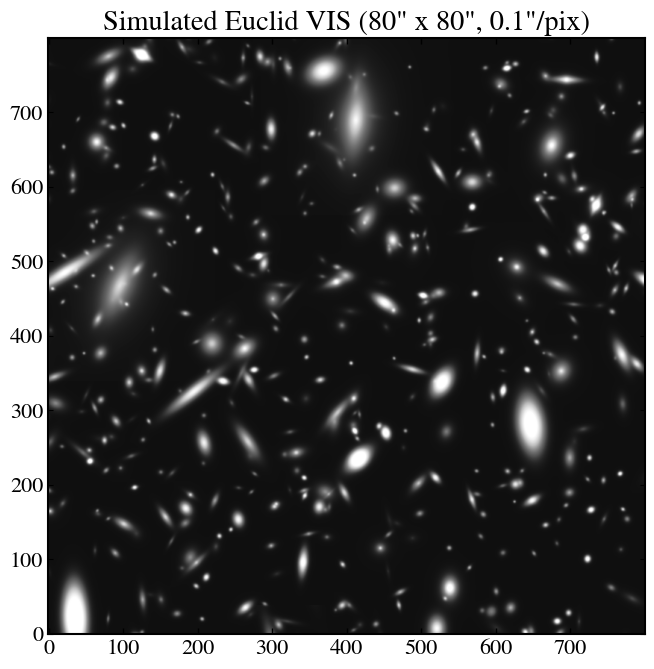

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
img = exp.image.array
ax.imshow(img, origin="lower", cmap="Greys_r",
          norm=simple_norm(img, "asinh", asinh_a=0.05, vmin=-0.05, vmax=5))
ax.set_title("Simulated Euclid VIS (80\" x 80\", 0.1\"/pix)")
plt.tight_layout()
plt.show()

## 4. Run the processor: detection + FPFS measurement

`AnacalTask.prepare_data` builds everything the measurement needs directly from
the LSST exposure (pixel scale, mag-zero, PSF, noise, processing blocks);
`run` returns a catalog with detection weights (`wdet`/`wsel`), FPFS
ellipticities (`fpfs_e1/e2`) and their shear responses.

**Key Euclid tuning:** the detection smoothing scale `sigma_arcsec` defaults to
0.40" (tuned for LSST's 0.7-0.8" PSF at 0.2"/pix). Euclid's PSF is only ~0.2"
at 0.1"/pix, so 0.40" over-smooths and destroys most detections. On this
noiseless image we use **`sigma_arcsec = 0.15`**: with no noise there are no
false positives, so a small smoothing detects deep into the real faint galaxies
(justified by the sweep in the next section).

In [6]:
def run_processor(exposure, sigma_arcsec=0.15, snr_min=5.0):
    ac = AnacalConfig()
    ac.do_noise_bias_correction = False   # no separate noise field here
    ac.sigma_arcsec = sigma_arcsec        # <-- main Euclid knob
    ac.snr_min = snr_min
    ac.npix = 64
    ac.bound = 40
    ac.force_center = True
    ac.force_size = False
    task = AnacalTask(config=ac)
    data = task.prepare_data(exposure=exposure, seed=1, band="vis")
    return task.run(**data)

cat = run_processor(exp, sigma_arcsec=0.15)
print(f"detected & measured {len(cat)} objects")

detected & measured 200 objects


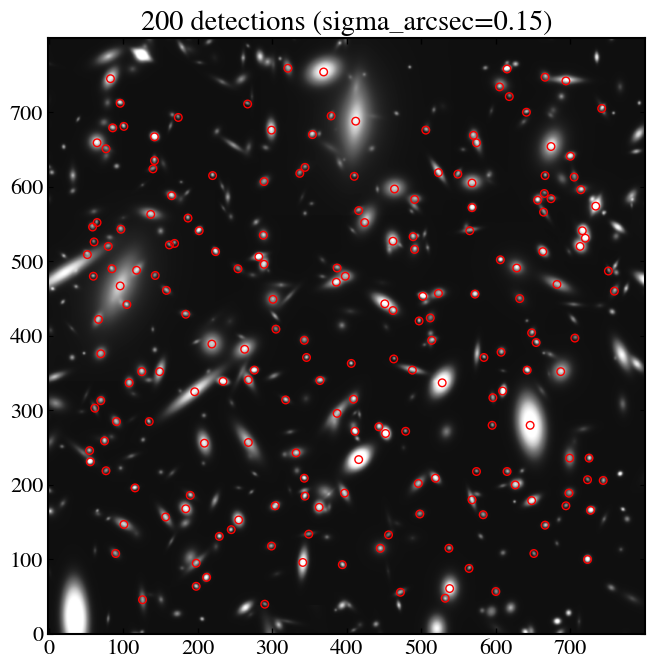

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, origin="lower", cmap="Greys_r",
          norm=simple_norm(img, "asinh", asinh_a=0.05, vmin=-0.05, vmax=5))
ax.scatter(cat["x1"] / 0.1, cat["x2"] / 0.1, s=30, facecolors="none",
           edgecolors="red", linewidths=1.0)
ax.set_title(f"{len(cat)} detections (sigma_arcsec=0.15)")
plt.tight_layout()
plt.show()

### Input galaxies vs detections

Overlay the **input** galaxy positions (truth, `VIS < 26.5`) and the
**detected** positions on the image. Blue `+` = input truth; red circles =
detections. Bboxes align with the array (patch XY0 = 0), so both use pixel =
position / 0.1.

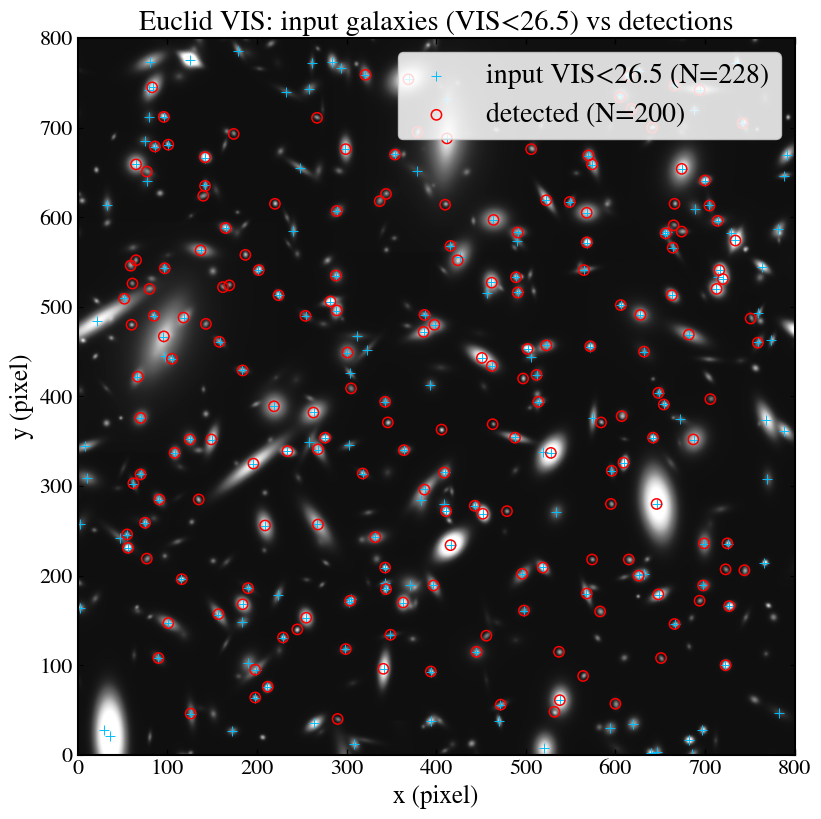

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.imshow(img, origin="lower", cmap="Greys_r",
          norm=simple_norm(img, "asinh", asinh_a=0.05, vmin=-0.05, vmax=5))

# input truth galaxies inside the patch with VIS < 26.5
sel = truth["euclid_vis"][inpatch] < 26.5
ax.scatter(px[inpatch][sel], py[inpatch][sel], s=45, marker="+",
           color="deepskyblue", linewidths=0.7,
           label=f"input VIS<26.5 (N={int(sel.sum())})")

# detected galaxies
ax.scatter(cat["x1"] / 0.1, cat["x2"] / 0.1, s=55, facecolors="none",
           edgecolors="red", linewidths=1.1,
           label=f"detected (N={len(cat)})")

ax.set_xlim(0, NPIX)
ax.set_ylim(0, NPIX)
ax.set_xlabel("x (pixel)")
ax.set_ylabel("y (pixel)")
ax.set_title("Euclid VIS: input galaxies (VIS<26.5) vs detections")
ax.legend(loc="upper right", framealpha=0.85)
plt.tight_layout()
plt.show()

## 5. Hyperparameter sensitivity: `sigma_arcsec`

Detection is very sensitive to the smoothing scale. On this noiseless image,
smaller `sigma_arcsec` = less smoothing = higher peak S/N for the compact
Euclid galaxies = deeper detection (no noise means no false-positive penalty).
The LSST default (0.40") over-smooths and finds almost nothing, while 0.15"
detects deep and recovers the input shear.

Note: **with real (correlated) noise you would raise `sigma_arcsec` and/or
`snr_min`** to keep noise-driven false detections under control — the best value
is noise-level dependent.

Other knobs to explore for Euclid (not swept here):
- `snr_min` (peak S/N threshold), `p_min`/`omega_p` (peak deblending),
  `npix`/`bound` (stamp size / boundary rejection).
- **Hard-coded in `AnacalTask.run`** (only scaled by `10^((mag_zero-30)/2.5)`):
  `omega_f`, `v_min`, `omega_v`, `fpfs_c0`. These were tuned for LSST
  (0.2"/pix, variance ~0.35) and are *not* exposed via `AnacalConfig`. Tuning
  them for Euclid requires editing `xlens/processor/anacal.py` or calling
  `anacal.task.Task` directly.

In [9]:
print(f"in-patch galaxies: {int(inpatch.sum())} "
      f"(VIS<24.5: {int((vis < 24.5).sum())}, VIS<25.5: {int((vis < 25.5).sum())})\n")
print(f"{'sigma_arcsec':>12} {'detected':>9} {'g1':>9}")
for sig in [0.15, 0.20, 0.25, 0.30, 0.40]:
    c = run_processor(exp, sigma_arcsec=sig)
    e1 = c["wsel"] * c["fpfs_e1"]
    de1 = c["dwsel_dg1"] * c["fpfs_e1"] + c["wsel"] * c["fpfs_de1_dg1"]
    g1 = np.sum(e1) / np.sum(de1) if np.sum(de1) else np.nan
    print(f"{sig:>12.2f} {len(c):>9d} {g1:>+9.4f}")

in-patch galaxies: 490 (VIS<24.5: 62, VIS<25.5: 117)

sigma_arcsec  detected        g1


        0.15       200   -0.0202


        0.20       112   -0.0318
        0.25        60   -0.0459


        0.30        33   -0.0439
        0.40        10   -0.0922


## 6. Shear estimate

FPFS shear estimator (selection-weighted), following
`example4_blended_sim_measure_match`:
$$\hat g_i = \frac{\sum w_{\rm sel}\, e_i}
                    {\sum (\partial_{g_i} w_{\rm sel}\, e_i
                     + w_{\rm sel}\, \partial_{g_i} e_i)}$$

Because the image is noiseless and detection is deep, a single realization here
already lands close to the input. It is still **not** a bias measurement — that
needs many seeds + the 90° ring-test rotation to beat down shape noise
(~0.3/√N per component) and expose percent-level multiplicative bias.

In [10]:
cat = run_processor(exp, sigma_arcsec=0.15)

def estimate_shear(c):
    e1 = c["wsel"] * c["fpfs_e1"]
    de1 = c["dwsel_dg1"] * c["fpfs_e1"] + c["wsel"] * c["fpfs_de1_dg1"]
    e2 = c["wsel"] * c["fpfs_e2"]
    de2 = c["dwsel_dg2"] * c["fpfs_e2"] + c["wsel"] * c["fpfs_de2_dg2"]
    return np.sum(e1) / np.sum(de1), np.sum(e2) / np.sum(de2)

g1, g2 = estimate_shear(cat)
print(f"g1 = {g1:+.4f}  (input {INPUT_G1})")
print(f"g2 = {g2:+.4f}  (input {INPUT_G2})")
print(f"N  = {len(cat)}  ->  shape-noise sigma ~ {0.3/np.sqrt(len(cat)):.3f} per comp.")

g1 = -0.0202  (input -0.02)
g2 = -0.0114  (input 0.0)
N  = 200  ->  shape-noise sigma ~ 0.021 per comp.


## Next steps

- **PSF realism:** replace the Moffat with an Airy (`galsim.Airy`, obscuration
  ~0.29, dilated to the measured FWHM) or a real `CATALOG-PSF` stamp
  (`InterpolatedImage`, `scale=0.1`, `method="no_pixel"`).
- **Correlated noise:** drive the sim with a measured 2D noise-correlation array
  instead of white noise (crucial for NISP; matters for VIS too).
- **Detection tuning:** expose/scan `omega_f`, `v_min`, `omega_v`, `fpfs_c0`
  for Euclid depth and pixel scale.
- **Bias:** run many seeds x 2 rotations and combine to measure multiplicative
  and additive bias, rather than reading a single realization.